# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

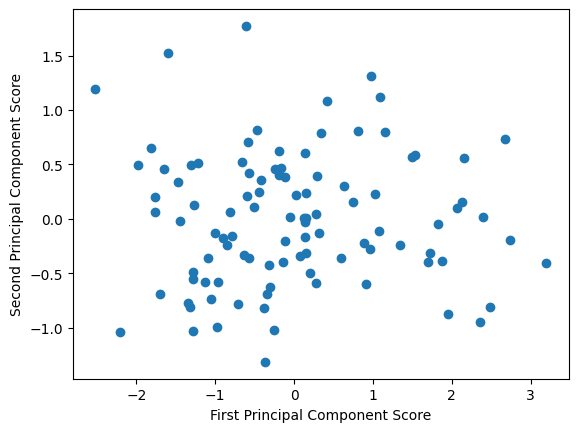

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

### Answer
#### The three outliers in the upper left corner of the PCA scatter plot have low first principal component (PC1) scores and high second principal component (PC2) scores. PC1 is dominated by ser3 so its low PC1 score means an unusually low ser3. PC2 is a mix of ser1 and ser2, so the high PC2 scores means high ser1 and ser2 values. However, because ser1 and ser2 are nearly linearly related, PCA can't tell us much about their relative values — only that both are high. This makes it easy to interpret ser3’s behavior, but difficult to separate ser1 from ser2. This makes sense since ser3 has a higher scale parameter applied compared to ser2, which makes ser1 and ser2 more closely related - just as the PCA shows us. The PCA plot is effective for spotting outliers and summarizing variance, but it obscures individual feature relationships.

In [2]:
# imports
import kagglehub
import os
import gc
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Download the datasets
olist_dataset_link = "olistbr/brazilian-ecommerce"
vgrecs_dataset_link = "antonkozyriev/game-recommendations-on-steam"
vgsales_dataset_link = "ashaheedq/video-games-sales-2019"

olist_path = kagglehub.dataset_download(olist_dataset_link)
vgrec_path = kagglehub.dataset_download(vgrecs_dataset_link)
vgsales_path = kagglehub.dataset_download(vgsales_dataset_link)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

# Video Game Sales Dataset

In [3]:
# Load Video Game Sales data
vgsales_df_raw = pd.read_csv(os.path.join(vgsales_path, "vgsales-12-4-2019-short.csv"))
vgsales_df_cleaned = vgsales_df_raw.dropna(subset=["Year"]).copy()
vgsales_df_cleaned["ESRB_Rating"] = vgsales_df_cleaned["ESRB_Rating"].fillna("RP")
vgsales_df_cleaned["Developer"] = vgsales_df_cleaned["Developer"].fillna("Unknown")
sales_cols = ["Global_Sales", "NA_Sales", "PAL_Sales", "JP_Sales", "Other_Sales"]
vgsales_df_cleaned[sales_cols] = vgsales_df_cleaned[sales_cols].fillna(0)
vgsales_df_cleaned = vgsales_df_cleaned[vgsales_df_cleaned["Year"] <= 2025]
regional_sum = vgsales_df_cleaned[["NA_Sales", "PAL_Sales", "JP_Sales", "Other_Sales"]].sum(axis=1)
vgsales_df_cleaned = vgsales_df_cleaned[vgsales_df_cleaned["Global_Sales"] >= regional_sum]
vgsales_df_cleaned = vgsales_df_cleaned.drop(columns=["Total_Shipped"])

# Impute null score values with median
# vgsales_df_cleaned['Critic_Score'] = vgsales_df_cleaned['Critic_Score'].fillna(vgsales_df_cleaned['Critic_Score'].median())
# vgsales_df_cleaned['User_Score'] = vgsales_df_cleaned['User_Score'].fillna(vgsales_df_cleaned['User_Score'].median())


# Encode Video Game Sales
vgsales_df_cleaned_encoded = vgsales_df_cleaned.copy()
# One-Hot Encoding: Genre and ESRB_Rating
vgsales_df_cleaned_encoded = pd.get_dummies(vgsales_df_cleaned_encoded, columns=["Genre", "ESRB_Rating"], prefix=["Genre", "ESRB"])
# Platform Encoding: Top 10 + “Other”, then one-hot encoding it
top_platforms = vgsales_df_cleaned_encoded["Platform"].value_counts().nlargest(10).index
vgsales_df_cleaned_encoded["Platform"] = vgsales_df_cleaned_encoded["Platform"].where(vgsales_df_cleaned_encoded["Platform"].isin(top_platforms), other="Other")
vgsales_df_cleaned_encoded = pd.get_dummies(vgsales_df_cleaned_encoded, columns=["Platform"], prefix="Platform")
# Frequency Encoding: Publisher and Developer
for col in ["Publisher", "Developer"]:
    freq_map = vgsales_df_cleaned_encoded[col].value_counts(normalize=True)
    vgsales_df_cleaned_encoded[col + "_freq"] = vgsales_df_cleaned_encoded[col].map(freq_map)
vgsales_df_cleaned_encoded = vgsales_df_cleaned_encoded.drop(columns=["Publisher", "Developer"])

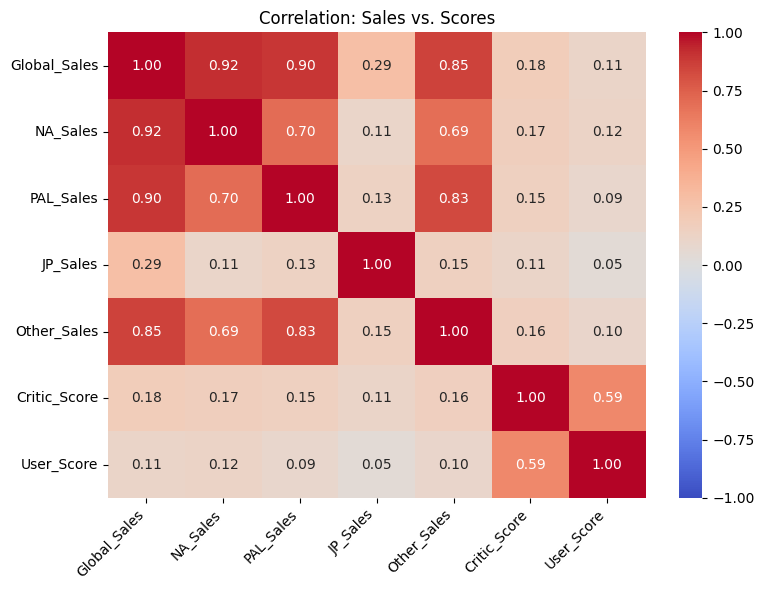

In [4]:
# correlation heatmap of sales and scores
sales_score_cols = [
    "Global_Sales", "NA_Sales", "PAL_Sales", "JP_Sales", "Other_Sales",
    "Critic_Score", "User_Score"
]

plt.figure(figsize=(8, 6))
corr_matrix = vgsales_df_cleaned[sales_score_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation: Sales vs. Scores")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


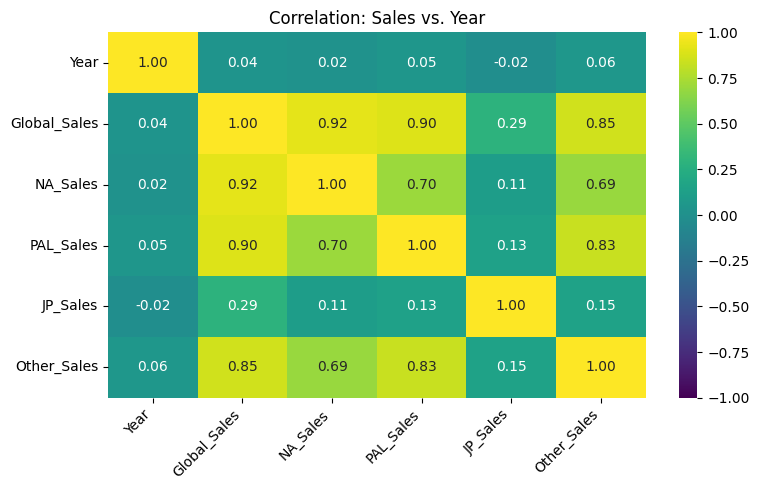

In [5]:
# correlation heatmap of sales and year
sales_year_cols = [
    "Year", "Global_Sales", "NA_Sales", "PAL_Sales", "JP_Sales", "Other_Sales"
]
plt.figure(figsize=(8, 5))
corr_matrix_year = vgsales_df_cleaned[sales_year_cols].corr()

sns.heatmap(corr_matrix_year, annot=True, fmt=".2f", cmap="viridis", vmin=-1, vmax=1)
plt.title("Correlation: Sales vs. Year")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


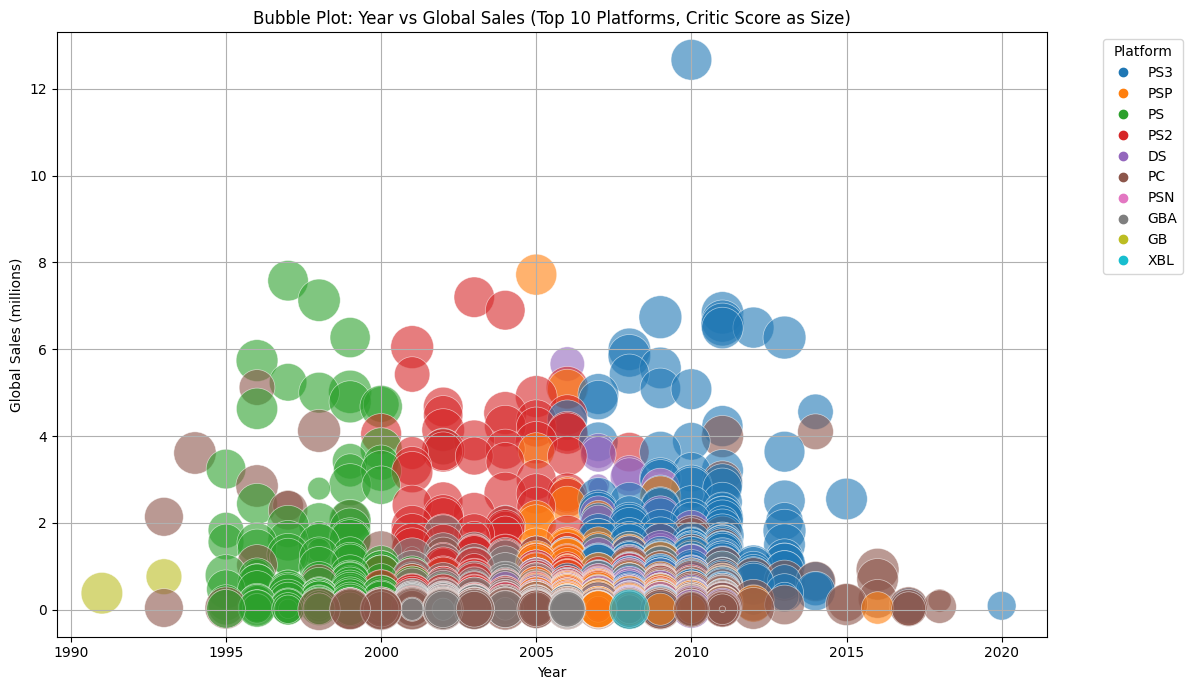

In [6]:
# bubble plot of year vs global sales, colored by platform, bubble size by critic score
top_platforms = vgsales_df_cleaned["Platform"].value_counts().nlargest(10).index

bubble_df = vgsales_df_cleaned[
    (vgsales_df_cleaned["Platform"].isin(top_platforms)) &
    (vgsales_df_cleaned["Global_Sales"] > 0)
][["Year", "Global_Sales", "Critic_Score", "Platform"]].dropna()

# Normalize critic score for bubble size
size = bubble_df["Critic_Score"]
normalized_size = (size - size.min()) / (size.max() - size.min()) * 1000 + 10

plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    x=bubble_df["Year"],
    y=bubble_df["Global_Sales"],
    s=normalized_size,
    c=pd.factorize(bubble_df["Platform"])[0],
    cmap="tab10",
    alpha=0.6,
    edgecolors="w",
    linewidths=0.5
)

plt.xlabel("Year")
plt.ylabel("Global Sales (millions)")
plt.title("Bubble Plot: Year vs Global Sales (Top 10 Platforms, Critic Score as Size)")
plt.grid(True)

# Legend
platform_labels = pd.factorize(bubble_df["Platform"])[1]
handles = [
    plt.Line2D([], [], marker='o', linestyle='', color=scatter.cmap(i / 10))
    for i in range(len(platform_labels))
]
plt.legend(handles, platform_labels, title="Platform", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


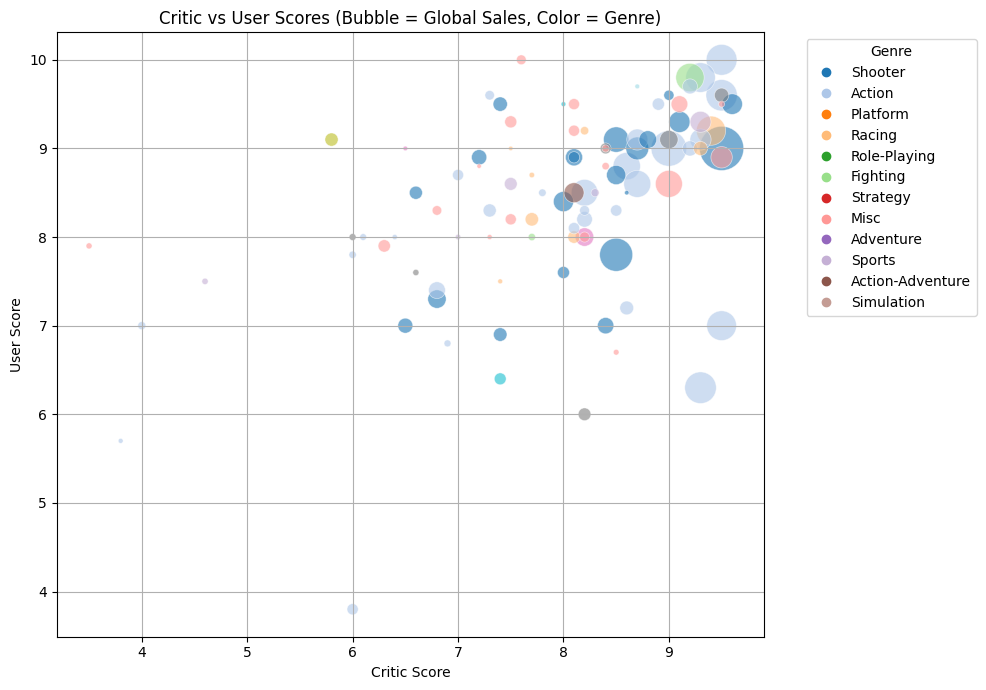

In [7]:
# bubble plot of critic score vs user score, color by genre bubble size by global sales

bubble_df2 = vgsales_df_cleaned[
    (vgsales_df_cleaned["Global_Sales"] > 0) &
    vgsales_df_cleaned["Genre"].notna() &
    vgsales_df_cleaned["Critic_Score"].notna() &
    vgsales_df_cleaned["User_Score"].notna()
][["Critic_Score", "User_Score", "Global_Sales", "Genre"]]

# Normalize size
size = bubble_df2["Global_Sales"]
normalized_size = (size - size.min()) / (size.max() - size.min()) * 1000 + 10

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    x=bubble_df2["Critic_Score"],
    y=bubble_df2["User_Score"],
    s=normalized_size,
    c=pd.factorize(bubble_df2["Genre"])[0],
    cmap="tab20",
    alpha=0.6,
    edgecolors="w",
    linewidths=0.5
)

plt.xlabel("Critic Score")
plt.ylabel("User Score")
plt.title("Critic vs User Scores (Bubble = Global Sales, Color = Genre)")
plt.grid(True)

# Legend for genre
genre_labels = pd.factorize(bubble_df2["Genre"])[1]
handles = [
    plt.Line2D([], [], marker='o', linestyle='', color=scatter.cmap(i / 20))
    for i in range(len(genre_labels))
]
plt.legend(handles, genre_labels, title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


3. Scores + Sales PCA
Goal: Identify which games are "score-driven" vs "sales-driven", and how much variance is captured in PC1/PC2.

4. All features PCA
    Goal: How well can we represent everything in 2D?
    Bonus: Use the PCA projection for plotting or outlier detection

5. Predict User_Score from Critic_Score + Metadata
    Goal: Are user scores predictable or chaotic? Is there bias?
Predict Global_Sales
    Predictors: Top encoded features (genres, platforms, critic/user scores, dev/pub frequency)
    Goal: Which features most drive sales?

Explained variance ratio: [0.592166  0.2184978]
Total variance captured: 0.811
PC1 Loadings:
 Global_Sales    0.485581
PAL_Sales       0.476461
Other_Sales     0.476439
NA_Sales        0.464215
JP_Sales        0.254460
Critic_Score    0.167093
User_Score      0.045130
dtype: float64

PC2 Loadings:
 User_Score      0.728576
Critic_Score    0.667860
NA_Sales       -0.045658
Global_Sales   -0.065178
JP_Sales       -0.067852
Other_Sales    -0.074697
PAL_Sales      -0.081384
dtype: float64


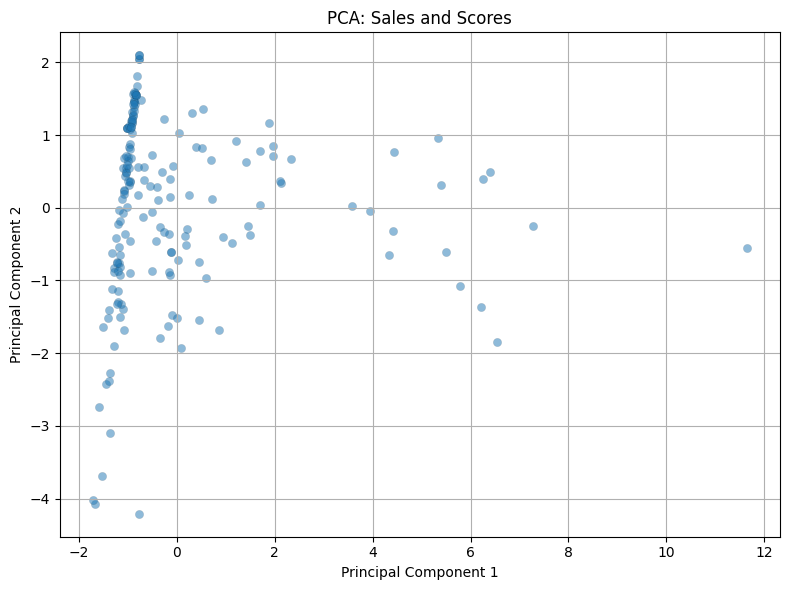

In [8]:
# PCA to analyse whether games are score-driven vs sales-driven

# features for PCA
pca_features = [
    "Critic_Score", "User_Score", 
    "Global_Sales", "NA_Sales", "PAL_Sales", "JP_Sales", "Other_Sales"
]
 
# clean it up and standardize data
pca_df = vgsales_df_cleaned[pca_features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

# 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# print variance ratios
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured:", round(sum(pca.explained_variance_ratio_), 3))

# print loadings
loadings = pd.Series(pca.components_[0], index=pca_df.columns)
print("PC1 Loadings:\n", loadings.sort_values(ascending=False))

loadings2 = pd.Series(pca.components_[1], index=pca_df.columns)
print("\nPC2 Loadings:\n", loadings2.sort_values(ascending=False))


# plot PCA results
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, edgecolor="k", linewidth=0.1)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: Sales and Scores")
plt.grid(True)
plt.tight_layout()
plt.show()


### PCA analysis of sales and scores shows that the PC1 captures 59.2% of the variance and is dominated by global and regional sales, making it a strong "sales axis" that distinguishes blockbuster games from low-sellers. PC2 captures 21.8% of the variance, and id driven by user and critic scores. PC2 is a "reception" axis that separates well-reviewed games from poorly received ones regardless of sales. These two components are 81% of the total variance, meaning the dataset can be reduced to two dimensions that show commercial success and critical reception.

Explained variance ratio: [0.38543398 0.14787515]
Total variance captured: 0.533


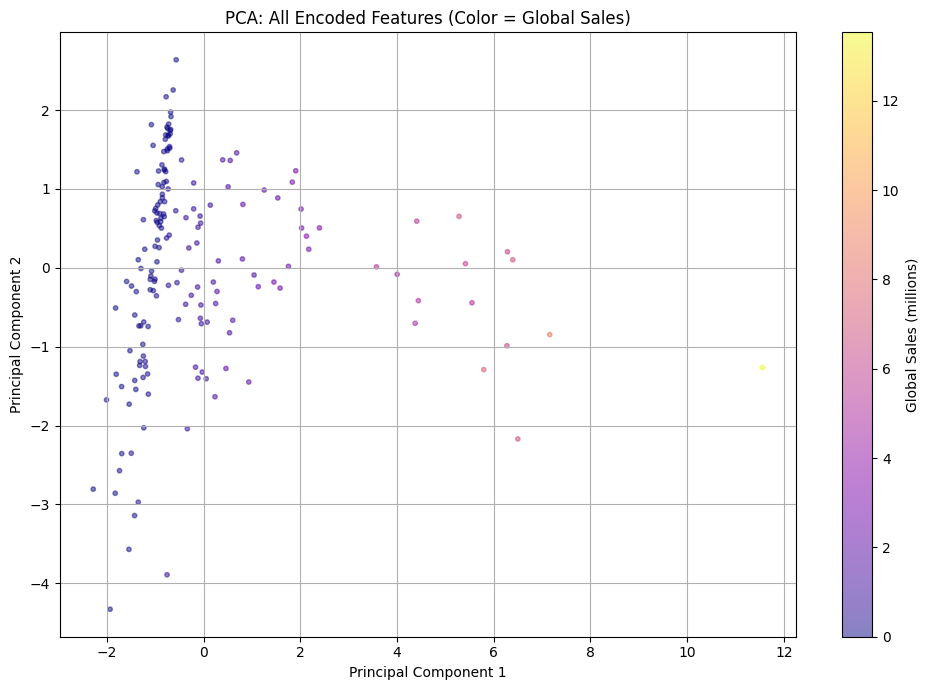

In [9]:
# Full-feature PCA (with all da features)

# drop nulls and keep numeric
pca_df_full = vgsales_df_cleaned_encoded.select_dtypes(include=["number"]).dropna()


# standardize
X_full = StandardScaler().fit_transform(pca_df_full)

# pca time
pca_full = PCA(n_components=2)
X_pca_full = pca_full.fit_transform(X_full)

print("Explained variance ratio:", pca_full.explained_variance_ratio_)
print("Total variance captured:", round(sum(pca_full.explained_variance_ratio_), 3))



# plot it
plt.figure(figsize=(10, 7))
plt.scatter(
    X_pca_full[:, 0], 
    X_pca_full[:, 1],
    c=pca_df_full["Global_Sales"], 
    cmap="plasma",
    s=10,
    alpha=0.5)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: All Encoded Features (Color = Global Sales)")
plt.colorbar(label="Global Sales (millions)")
plt.grid(True)
plt.tight_layout()
plt.show()



### The PCA on all the encoded features captured 53.3% of the total variance in two components —  PC1 accounts for 38.5%, and PC2 for 14.8%. This means that while some structure is preserved, the data is less compressible than the simpler scores + sales subset. That’s expected with the one-hot encoded genre, platform, and ESRB rating features introducing high dimensionality and sparsity. Visually, the scatter plot still shows a clear separation — with high-sales games isolated on the far right, showing that PC1 is heavily influenced by sales-related variables. The vertical spread in PC2 could reflect variation in genre, platform, or score preferences (idk). Outliers on the far right are likely top-selling blockbusters with unique feature combinations (top platforms, top genres, high scores, etc).

In [10]:
# Linear regression to Predict User_Score from Critic_Score + Metadata

# drop rows with user score missing
reg_df = vgsales_df_cleaned_encoded.dropna()
# fefine X and y, keep only numerics
X = reg_df.drop(columns=["User_Score", "Global_Sales"]).select_dtypes(include=["number"])
y = reg_df["User_Score"]


# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

R² Score: 0.317
RMSE: 0.734


### the linear regression model used to predict User_Score from critic scores, platform, genre, ESRB rating, and developer/publisher metadata got an R² of 0.317 and an RMSE of 0.734. This means that the model explains 32% of the variation in user scores, with most predictions falling with a 7.3% error. While there is some predictive signal, user sentiment is mostly unpredictable using the available metadata. This shows that user scores are influenced by factors like hype, bugs, marketing, and probably subjective biases not captured in the dataset. Overall, the results suggest that user reviews are only partially grounded in the same features that drive professional assessments.

In [11]:
# Linear regression to Predict global sales from all the metadata

# drop rows with missing Global_Sales or predictors
reg_df_sales = vgsales_df_cleaned_encoded.dropna()


# Drop User_Score and Critic_Score entirely to avoid massive row loss
X_sales = vgsales_df_cleaned_encoded.drop(
    columns=[
        "Global_Sales", "User_Score", "Critic_Score",
        "NA_Sales", "PAL_Sales", "JP_Sales", "Other_Sales"
    ]
).select_dtypes(include=["number"])

y_sales = vgsales_df_cleaned_encoded["Global_Sales"]


# test train split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sales, y_sales, test_size=0.2, random_state=42)

# initialize model
model_sales = LinearRegression()
model_sales.fit(X_train_s, y_train_s)
y_pred_s = model_sales.predict(X_test_s)

# evaluation
r2_s = r2_score(y_test_s, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))

print(f"R² Score: {r2_s:.3f}")
print(f"RMSE: {rmse_s:.3f}")


R² Score: 0.122
RMSE: 0.438


### This linear model predicted global sales from game metadata, and achieved an R2 score of 0.122 and an RMSE of 0.438. This shows us that the model explains only about 12% of the variance in sales, with most of the predictions deviating by nearly 500k units. While genre, platform, ESRB rating, and developer/publisher popularity give us some some weak signal, they arent enough on their own to reliably predict commercial success. These results highlight the importance of external factors such as marketing, brand strength, and critical reception. Linear regression alone is likely not enough to model the more complex relationships the available metadata has when it comes to predicting sales.

# Video Game Sales Conclusions

### Through this analysis of the video game sales dataset, heatmaps revealed that critic and user scores have only a weak correlation with sales, while regional sales are well interrelated. Bubble plots showed clear patterns that high-selling games concentrated in specific years and platforms, with critic scores offering SOME insight into commercial performance. PCA on scores and sales got over 81% of the variance in two components, allowing effective dimensionality reduction. However, the full-feature PCA showed the data was less compressible, capturing only 53% of the variance, which is still useful for visual clustering and outlier detection. 

### Linear regression showed that critic scores offers a little bit of predictive value for user scores (R2 = 0.32), while metadata like genre, platform, and publisher/developer popularity are weak predictors of global sales (R2 = 0.12). Overall, the dataset is still usable and shows meaningful structure, but it lacks many of the key drivers of game success like marketing and brand power, which limits how well we can predict success later. PCA and correlation analysis both helped inform the modeling approach, and we can see outliers in both the PCA plots and the score vs sales bubbles, highlighting games that overperformed or underperformed relative to its success.

# Video Game Recommendations Dataset

In [ ]:
# Load Video Game Recommendations data
vgrecs_recs_df_raw = pd.read_csv(os.path.join(vgrec_path, "recommendations.csv"))
vgrecs_users_df_raw = pd.read_csv(os.path.join(vgrec_path, "users.csv"))
vgrecs_games_df_raw = pd.read_csv(os.path.join(vgrec_path, "games.csv"))
vgrecs_game_metadata_path = os.path.join(vgrec_path, "games_metadata.json")
meta_df = pd.read_json(vgrecs_game_metadata_path, lines=True)


vgrecs_merged_df = vgrecs_recs_df_raw.merge(vgrecs_users_df_raw, on="user_id", how="left")
vgrecs_merged_df = vgrecs_merged_df.merge(vgrecs_games_df_raw, on="app_id", how="left")
vgrecs_merged_df["date_release"] = pd.to_datetime(vgrecs_merged_df["date_release"], errors="coerce")

# keep only app_id + first tag = genre
tag_lookup = (
    meta_df
      .assign(genre=lambda d: d["tags"].str[0])
      .loc[:, ["app_id", "genre"]]
      .drop_duplicates("app_id")
)

vgrecs_merged_df = vgrecs_merged_df.merge(tag_lookup, on="app_id", how="left")
vgrecs_merged_df["genre"] = vgrecs_merged_df["genre"].fillna("No Category")

print(f"Raw: {vgrecs_merged_df.shape}")
# cut data in quarter because it is too large for my kernel
vgrecs_merged_df = vgrecs_merged_df.sample(frac=0.10, random_state=42)
# remove anything with price over 175, it makes no sense to unneccesarily distort games
vgrecs_merged_df = vgrecs_merged_df[vgrecs_merged_df["price_final"] <= 175]

print(f"Cleaned: {vgrecs_merged_df.shape}")

# clean up the unused dataframes
del vgrecs_recs_df_raw
del vgrecs_users_df_raw
del vgrecs_games_df_raw
del meta_df
gc.collect()

# Encode Video Game Recommendations
vgrecs_merged_df_encoded = vgrecs_merged_df.copy()
rating_order = ['Overwhelmingly Negative', 'Very Negative', 'Mostly Negative', 'Negative', 'Mixed', 'Positive', 'Mostly Positive', 'Very Positive', 'Overwhelmingly Positive']
rating_map = {label: idx for idx, label in enumerate(rating_order)}
vgrecs_merged_df_encoded['rating_encoded'] = vgrecs_merged_df_encoded['rating'].map(rating_map)

Raw: (41154794, 23)
Cleaned: (4115463, 23)


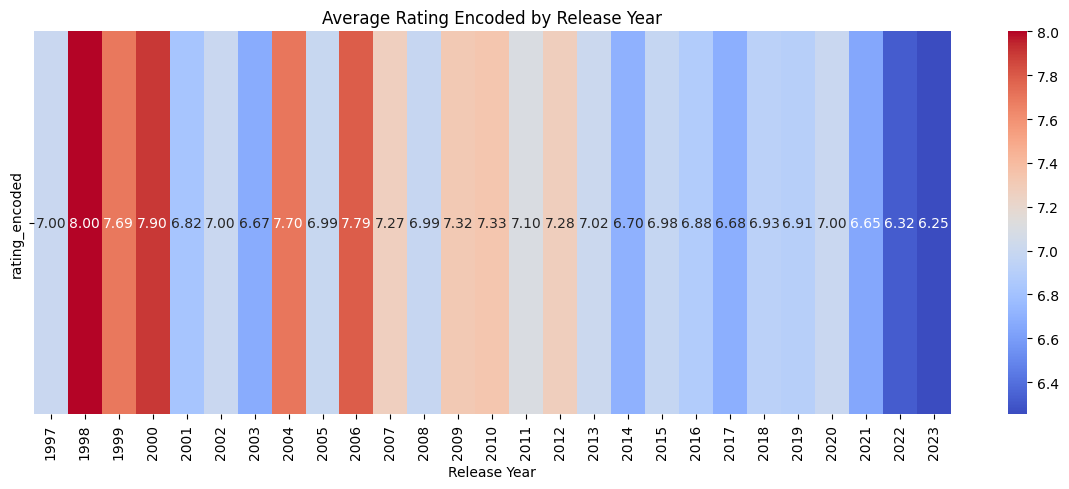

In [18]:
# heatmap: year of release vs. average Rating

vgrecs_merged_df_encoded["release_year"] = vgrecs_merged_df_encoded["date_release"].dt.year


year_rating_df = (
    vgrecs_merged_df_encoded
    .dropna(subset=["rating_encoded", "release_year"])
    .groupby("release_year")["rating_encoded"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.heatmap(
    year_rating_df.set_index("release_year").T,
    cmap="coolwarm", annot=True, fmt=".2f"
)
plt.title("Average Rating Encoded by Release Year")
plt.xlabel("Release Year")
plt.tight_layout()
plt.show()


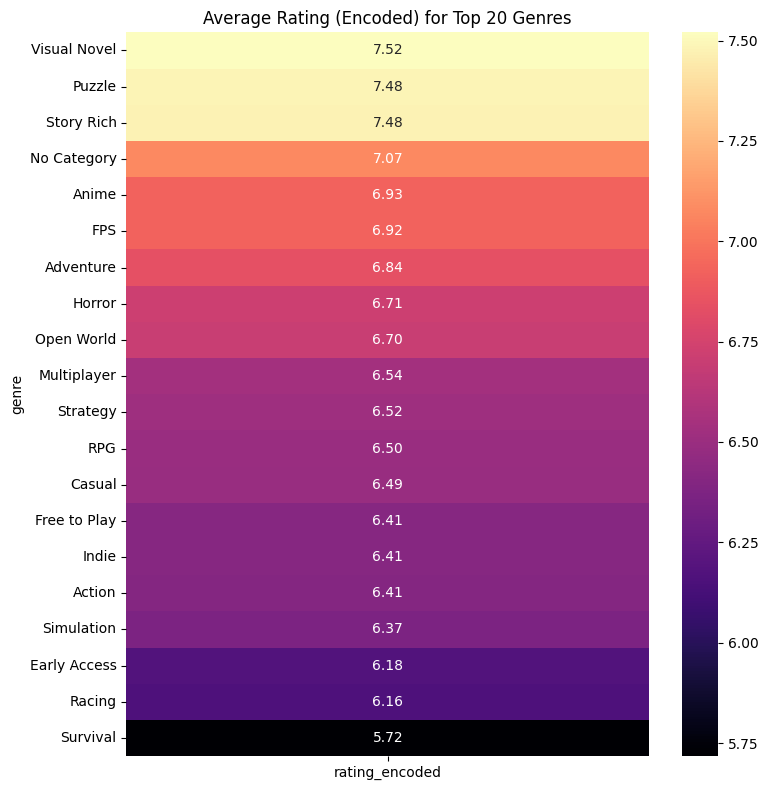

In [20]:
# heatmap of ratings by genre

# count top 20 genres
top_20_genres = (
    vgrecs_merged_df_encoded["genre"]
    .value_counts()
    .head(20)
    .index
)

# filter to top 20
genre_rating_df_top20 = (
    vgrecs_merged_df_encoded[
        vgrecs_merged_df_encoded["genre"].isin(top_20_genres)
    ]
    .dropna(subset=["rating_encoded"])
    .groupby("genre")["rating_encoded"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# plot
plt.figure(figsize=(8, 8))
sns.heatmap(
    genre_rating_df_top20.set_index("genre"),
    annot=True,
    cmap="magma",
    fmt=".2f"
)
plt.title("Average Rating (Encoded) for Top 20 Genres")
plt.tight_layout()
plt.show()


### These heatmaps show trends in user ratings across time and genre. Games released between 1998 and 2000 received the highest average ratings, while more recent titles (especially those released after 2020) show a noticeable decline, suggesting a shift in user expectations, increased volume of lower-quality releases, or more polarized reviewing behavior in recent years. Genre-wise, niche categories like Visual Novel, Puzzle, and Story Rich consistently received the highest average ratings, probably driven by very dedicated fanbases. In contrast, genres like Survival, Racing, and Early Access scored lowest, possibly reflecting unfinished or buggy releases and genre-specific expectations that are harder to satisfy. These patterns suggest that both release timing and genre strongly influence how games are rated by users.

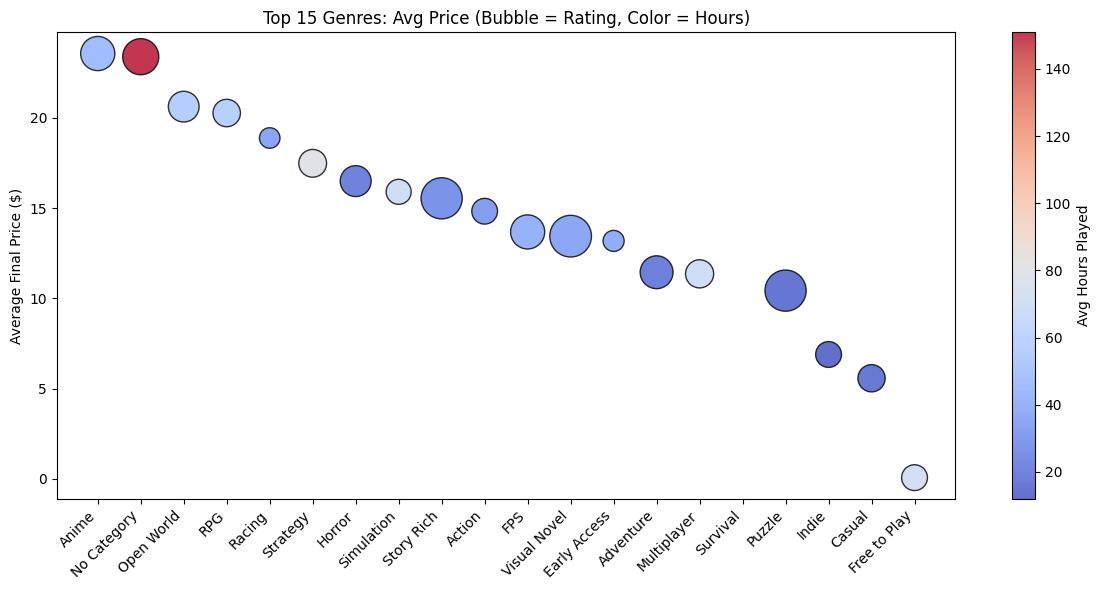

In [32]:
# bubbble plot of Average Rating vs Average Price by top 15 genres

top_genres = (
    vgrecs_merged_df_encoded["genre"]
    .value_counts()
    .head(20)
    .index
)

grouped_bubble_df = (
    vgrecs_merged_df_encoded[
        vgrecs_merged_df_encoded["genre"].isin(top_genres)
    ]
    .dropna(subset=["rating_encoded", "price_final", "hours"])
    .groupby("genre")
    .agg({
        "price_final": "mean",
        "rating_encoded": "mean",
        "hours": "mean"
    })
    .reset_index()
)
# descending order
grouped_bubble_df = grouped_bubble_df.sort_values(by="price_final", ascending=False)


# plot it
plt.figure(figsize=(12, 6))

sizes = (grouped_bubble_df["rating_encoded"] - grouped_bubble_df["rating_encoded"].min()) * 500
colors = grouped_bubble_df["hours"]

scatter = plt.scatter(
    grouped_bubble_df["genre"],
    grouped_bubble_df["price_final"],
    s=sizes,
    c=colors,
    cmap="coolwarm",
    edgecolors="k",
    alpha=0.8
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Final Price ($)")
plt.title("Top 15 Genres: Avg Price (Bubble = Rating, Color = Hours)")
plt.colorbar(label="Avg Hours Played")
plt.tight_layout()
plt.show()


### This bubble plot shows that higher-priced genres like "Story Rich", "Puzzle", and games without a category tend to have higher ratings and longer playtimes. In contrast, genres like "Free to Play" and "Casual" have low prices (obviously), lower ratings, and shorter play sessions. Overall, genres with deeper or more engaging content justify higher prices and receive better user reception.

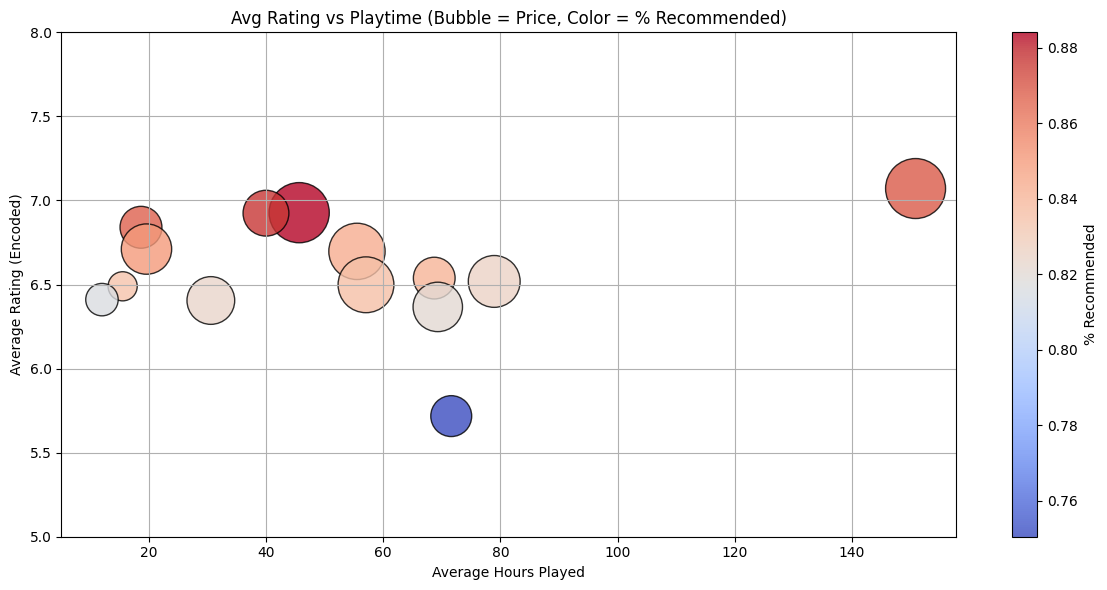

In [30]:
# bubble plot of playtime vs rating, bubble size = price

top_genres = (
    vgrecs_merged_df_encoded["genre"]
    .value_counts()
    .head(15)
    .index
)

bubble_df = (
    vgrecs_merged_df_encoded[
        vgrecs_merged_df_encoded["genre"].isin(top_genres)
    ]
    .dropna(subset=["hours", "rating_encoded", "price_final"])
    .groupby("genre")
    .agg({
        "hours": "mean",
        "rating_encoded": "mean",
        "price_final": "mean",
        "is_recommended": "mean"
    })
    .reset_index()
)

plt.figure(figsize=(12, 6))

sizes = (bubble_df["price_final"] - bubble_df["price_final"].min()) * 80
colors = bubble_df["is_recommended"]

scatter = plt.scatter(
    bubble_df["hours"],
    bubble_df["rating_encoded"],
    s=sizes,
    c=colors,
    cmap="coolwarm",
    edgecolors="k",
    alpha=0.8
)

plt.xlabel("Average Hours Played")
plt.ylabel("Average Rating (Encoded)")
plt.title("Avg Rating vs Playtime (Bubble = Price, Color = % Recommended)")
plt.colorbar(label="% Recommended")
plt.ylim((5, 8))
plt.grid(True)
plt.tight_layout()
plt.show()

### this plot shows that genres with longer average playtimes receive higher ratings and recommendation rates, as indicated by larger bubbles and warmer colors. One standout genre combines high playtime, high ratings, and a strong recommendation percentage—suggesting strong user engagement and satisfaction. In contrast, genres with moderate playtime but lower ratings and recommendation percentages look less favorable by rating, which shows a potential mismatch between playtime and perceived quality.

Explained variance ratio: [0.24124184 0.18527834]
Total variance captured: 0.427
                     PC1       PC2
hours           0.051781  0.069692
helpful        -0.026384  0.702943
funny          -0.014973  0.702596
positive_ratio  0.701270  0.010530
user_reviews    0.064189  0.072932
price_final     0.051330  0.025376
discount       -0.051433 -0.032876
rating_encoded  0.703718  0.014777


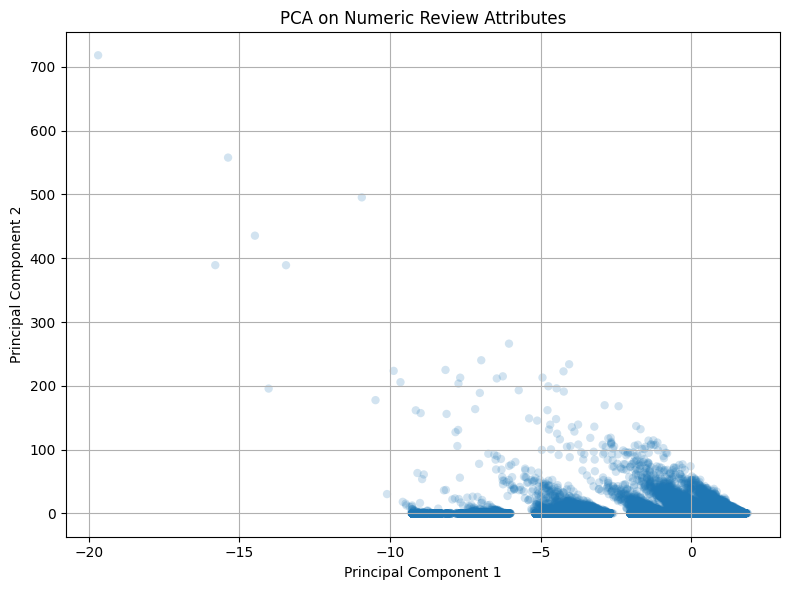

In [34]:
# PCA analysis of all numeric features

# selecting features
pca_features = [
    "hours", "helpful", "funny", "positive_ratio", 
    "user_reviews", "price_final", "discount", "rating_encoded"
]

# frop missing
pca_df = vgrecs_merged_df_encoded[pca_features].dropna()

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

# run pca
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# print variance ratios
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured:", round(sum(pca.explained_variance_ratio_), 3))

# print loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=pca_features,
    index=["PC1", "PC2"]
)
print(loadings.T)


#plot
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.2, edgecolors='none')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Numeric Review Attributes")
plt.grid(True)
plt.tight_layout()
plt.show()



### this PCA analysis of review attributes shows two behavioral axes. PC1 captures 24.1% of the variance, it is dominated by rating_encoded and positive_ratio, making it a clear measure of overall user sentiment or game reception. PC2 captured 18.5%, is dominated by helpful and funny vote counts, highlighting a review's social engagement or virality. Together, these components distinguish between games that are highly rated versus those that get a lot of attention. Features like hours played, price, and discount contributed little to either axis, suggesting that perceived quality and popularity are independent of playtime or pricing behavior.

In [ ]:
# Linear regression to predict a game's rating

# drop rows with missing values
df_rating = vgrecs_merged_df_encoded.dropna(subset=["rating_encoded", "price_final", "discount", "hours"])

# Sample 10% to reduce memory load
df_rating = df_rating.sample(frac=0.10, random_state=42)

# one hot encode genre and platform flags
df_rating = pd.get_dummies(
    df_rating,
    columns=["genre", "win", "mac", "linux", "steam_deck"],
    drop_first=True
)


# define aces
X_rating = df_rating[["price_final", "discount", "hours"] + 
                     [col for col in df_rating.columns if col.startswith("genre_") or col.startswith("win") or col.startswith("mac") or col.startswith("linux") or col.startswith("steam_deck")]]
y_rating = df_rating["rating_encoded"]

# train test split yeehaw
X_train, X_test, y_train, y_test = train_test_split(X_rating, y_rating, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


# evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2 Score: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

: 

# Video Game Recommendations Conclusions

# Olist ECommerce Dataset

# Olist Conclusions

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

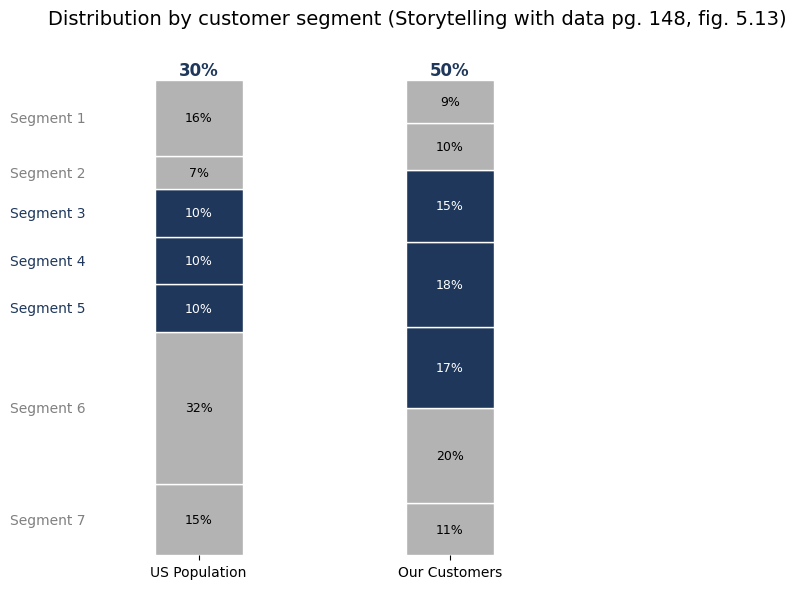

In [13]:
# segment labels and values - idk if this is right
segments = [
    "Segment 1", "Segment 2", "Segment 3",
    "Segment 4", "Segment 5", "Segment 6", "Segment 7"
]
# data
us_population = [16, 7, 10, 10, 10, 32, 15]
our_customers = [9, 10, 15, 18, 17, 20, 11]

# define which segments to highlight
highlight_segments = ["Segment 3", "Segment 4", "Segment 5"]
colors = ['#B3B3B3' if seg not in highlight_segments else '#1E375B' for seg in segments]

# reverse order for stacking from bottom to the top
segments = segments[::-1]
us_population = us_population[::-1]
our_customers = our_customers[::-1]
colors = colors[::-1]

# subpot setup
fig, ax = plt.subplots(figsize=(6, 6))
bar_width = 0.35
# vertical bar positions
x = [0, 1]

# track vertical positions for label alignment
us_bottom = 0
cust_bottom = 0
#iterate through segmenrts
for i in range(len(segments)):
    # US population bar
    ax.bar(x[0], us_population[i], bottom=us_bottom, color=colors[i], width=bar_width, edgecolor='white')
    ax.text(x[0], us_bottom + us_population[i]/2, f"{us_population[i]}%", ha='center', va='center',
            color='white' if colors[i] != '#B3B3B3' else 'black', fontsize=9)

    # our customers bar
    ax.bar(x[1], our_customers[i], bottom=cust_bottom, color=colors[i], width=bar_width, edgecolor='white')
    ax.text(x[1], cust_bottom + our_customers[i]/2, f"{our_customers[i]}%", ha='center', va='center',
            color='white' if colors[i] != '#B3B3B3' else 'black', fontsize=9)

    # segment labels on the left side
    label_color = '#1E375B' if segments[i] in highlight_segments else 'gray'
    ax.text(-0.45, us_bottom + us_population[i]/2, segments[i], va='center', ha='right', fontsize=10, color=label_color)

    us_bottom += us_population[i]
    cust_bottom += our_customers[i]

# add percentage annotations
ax.text(x[0], 101, "30%", ha='center', fontsize=12, fontweight='bold', color='#1E375B')
ax.text(x[1], 101, "50%", ha='center', fontsize=12, fontweight='bold', color='#1E375B')

# axis labels and stuff
ax.set_xlim(-0.6, 1.5)
ax.set_ylim(0, 110)
ax.set_xticks(x)
ax.set_xticklabels(["US Population", "Our Customers"], fontsize=10)
ax.set_yticks([])
ax.set_title("Distribution by customer segment (Storytelling with data pg. 148, fig. 5.13)", fontsize=14, loc='left')

# hide the outer lines
for line in ['top', 'right', 'left', 'bottom']:
    ax.spines[line].set_visible(False)

plt.tight_layout()
plt.show()
